# Part 1: Image Data

---
## Mô tả Dataset: Fashion MNIST

### 1. Nguồn dữ liệu
- **Dataset**: Fashion MNIST
- **Link Kaggle**: https://www.kaggle.com/datasets/zalando-research/fashionmnist

### 2. Cấu trúc file .csv

| Cột | Kiểu dữ liệu | Mô tả |
|-----|--------------|-------|
| **label** | integer (int) | Nhãn lớp của ảnh (0–9), biểu diễn loại trang phục |
| **pixel1** | integer (int) | Giá trị điểm ảnh đầu tiên (0–255) |
| **pixel2** | integer (int) | Giá trị điểm ảnh thứ hai (0–255) |
| **...** | ... | ... |
| **pixel784** | integer (int) | Giá trị điểm ảnh thứ 784 (0–255) |


# Import thư viện


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Đọc dữ liệu


In [2]:
df = pd.read_csv("../data/images/fashion-mnist_test.csv")

y = df['label'].values
X = df.drop('label',axis=1).values

X = X.reshape(-1,28,28).astype(np.uint8)

print("Image shape: ",X.shape)

Image shape:  (10000, 28, 28)


---
## a) Loading and Resizing

#### **Yêu cầu bài làm**
-  First, load images from the selected dataset. 
- Then, resize images to a consistent
dimension (e.g., 224 × 224, 128 × 128), and explain the rationale for choosing the specific dimensions.
- Finally, discuss the trade-offs between image size and computational efficiency.

#### **Thay đổi kích thước ảnh với các phương pháp nội suy khác nhau**

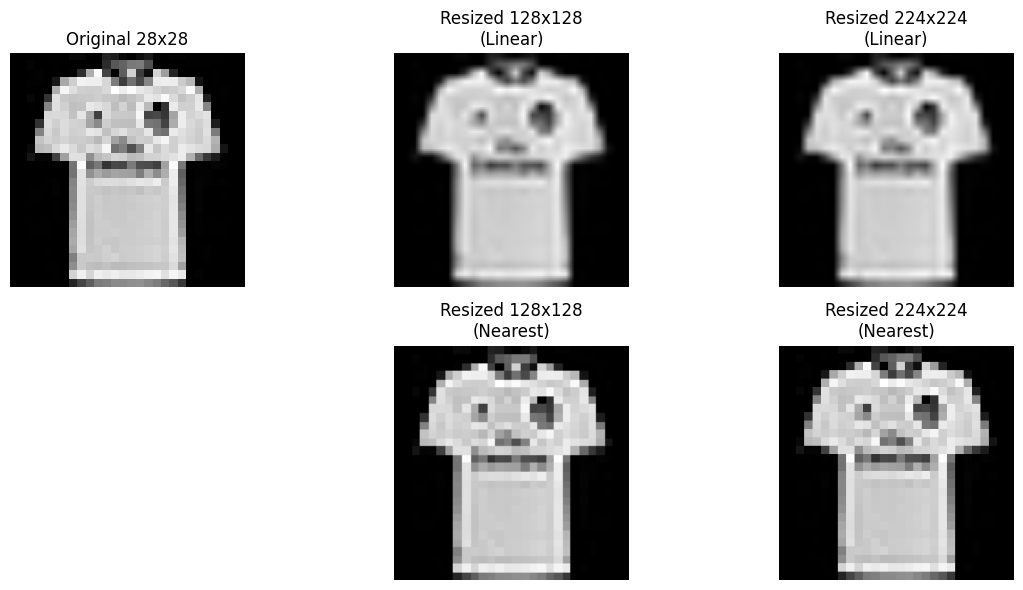

In [3]:
img = X[0]

resized128_linear = cv2.resize(img, (128,128), interpolation=cv2.INTER_LINEAR)
resized128_nearest = cv2.resize(img, (128,128), interpolation=cv2.INTER_NEAREST)
resized256_linear = cv2.resize(img, (224,224), interpolation=cv2.INTER_LINEAR)
resized256_nearest = cv2.resize(img, (224,224), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.title("Original 28x28")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Resized 128x128\n(Linear)")
plt.imshow(resized128_linear, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Resized 224x224\n(Linear)")
plt.imshow(resized256_linear, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Resized 128x128\n(Nearest)")
plt.imshow(resized128_nearest, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Resized 224x224\n(Nearest)")
plt.imshow(resized256_nearest, cmap='gray')
plt.axis('off')

plt.tight_layout()


plt.show()


Nhận xét: Thay đổi kích thước từ ảnh 28x28 lên kích thước 128x128 và 224x224 bằng phương pháp nội suy INTER_LINEAR sẽ cho thấy ảnh ra rõ nét hơn so với phương pháp INTER_NEAREST và kích thước 128x128 so với 224x224 không có sự khác biệt quá nhiều nên muốn trực quan hóa tốt hơn để dễ quan sát thì nên resize về 128x128 với phương pháp INTER_LINEAR thay vì 224x244 để tiết kiệm chi phí tính toán. Ngoài ra cũng nên cân nhắc resize nếu các mô hình deeplearning yêu cầu input ảnh là 224x224 như VGG,ResNet,... [VGG](https://arxiv.org/pdf/1409.1556v)

---
## b) Grayscale Conversion

#### **Yêu cầu bài làm**
-  Convert color images to grayscale where appropriate, then compare information.
retention between color and grayscale representations. 
- Discuss when grayscale conversion is beneficial
versus detrimental.
#### **Phương hướng làm bài**
Vì tập dữ liệu này chỉ gồm ảnh xám (1 kênh), nên không cần thực hiện bước chuyển đổi.
Tuy nhiên, với ảnh màu RGB, ảnh xám thường được tính theo công thức độ sáng (luminance):

Gray = 0.299R + 0.587G + 0.114B 

Trong đó mắt người nhạy cảm nhất với kênh Green nên trọng số của G lớn nhất.

### Tham khảo: [Grayscale](https://en.wikipedia.org/wiki/Grayscale)
---

### Pseudocode

For each pixel (R, G, B):

    gray = 0.299*R + 0.587*G + 0.114*B
    
    output(x, y) = gray

---
### Thảo luận
- So sánh về khả năng lưu trữ thông tin: Nếu là ảnh màu thì có vẻ sẽ thêm được thông tin về màu sắc của vật thể tuy nhiên chỉ để ảnh xám vẫn giữ được thông tin chính để có thể phân biệt giữa các vật thể nên cũng không quá quan trọng có màu, có thể giảm phần lớn về chi phí tính toán
- Khi nào nên chuyển đổi thành ảnh gray: khi bài toán là shape/edge/texture, tập dataset lớn cần xử lí nhanh hơn. Ví dụ một số bài toán như: Chữ viết tay, X-Ray và trong bài toán Fashion-MNIST này cũng chỉ cần ảnh xám là đủ
- Khi nào không nên chuyển đổi thành ảnh gray: Nếu màu là feature chính, nhận dạng vật thể theo màu. Ví dụ như: nhận diện trái cây, phân loại hoa,...

---
## c) Normalization

#### **Yêu cầu bài làm**
-  Apply pixel normalization (e.g., scaling to [0,1] or [-1,1]) and implement standardization
(zero mean, unit variance). 
- Then, compare different normalization techniques and their effects on the
data distribution.

In [4]:
img = X[0]

min_value = img.min()
max_value = img.max()

print("Giá trị pixel min/max là: ",min_value,max_value)

## Chuẩn hóa min-max [0,1]

img_01 = (img - min_value) / (max_value - min_value)

## Chuẩn hóa min-max [-1,1]
img_m11 = 2 * img_01 - 1


## standardized


global_mean = X.mean()
global_std = X.std()



X_standardized = (X - global_mean) / global_std

img_standardized = X_standardized[0]

print("Khoảng chuẩn hóa [0,1]: ", img_01.min(),img_01.max())
print("Khoảng chuẩn hóa [-1,1]: ", img_m11.min(),img_m11.max())
print("Chuẩn hóa mean/std: ",X_standardized.mean(),X_standardized.std())


Giá trị pixel min/max là:  0 255
Khoảng chuẩn hóa [0,1]:  0.0 1.0
Khoảng chuẩn hóa [-1,1]:  -1.0 1.0
Chuẩn hóa mean/std:  2.3027384987490593e-17 1.0000000000000002


#### **So sánh kết quả sau chuẩn hóa**

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

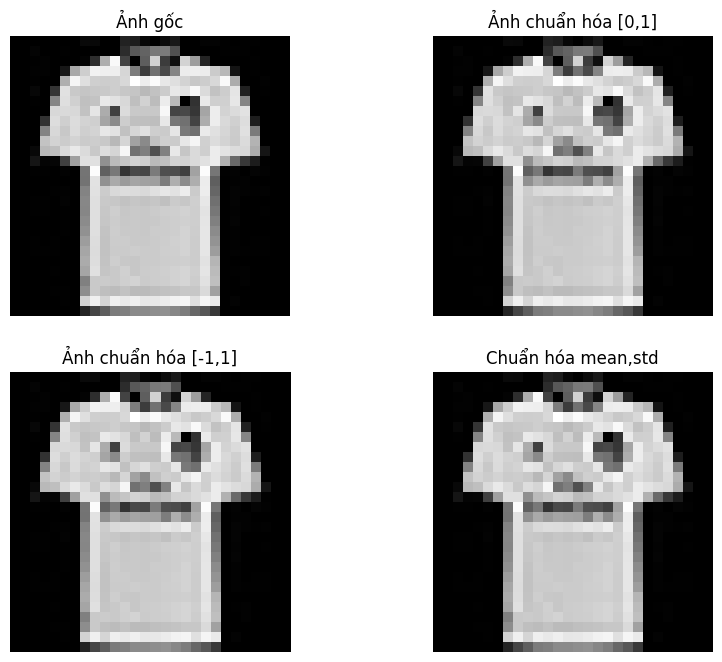

In [5]:

fig = plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_01, cmap='gray')
plt.title("Ảnh chuẩn hóa [0,1]")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_m11, cmap='gray')
plt.title("Ảnh chuẩn hóa [-1,1]")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_standardized, cmap='gray')
plt.title("Chuẩn hóa mean,std")
plt.axis('off')



Nhận xét: Qua so sánh trực quan, tất cả các hình ảnh đã được chuẩn hóa đều gần như giống hệt hình ảnh gốc. Điều này là điều dễ hiểu vì các kỹ thuật chuẩn hóa như chia tỷ lệ min-max và chuẩn hóa là các phép biến đổi tuyến tính chỉ thay đổi thang đo số của giá trị pixel mà không làm thay đổi cấu trúc không gian hoặc mối quan hệ cường độ tương đối.

#### **So sảnh phân phối histogram**

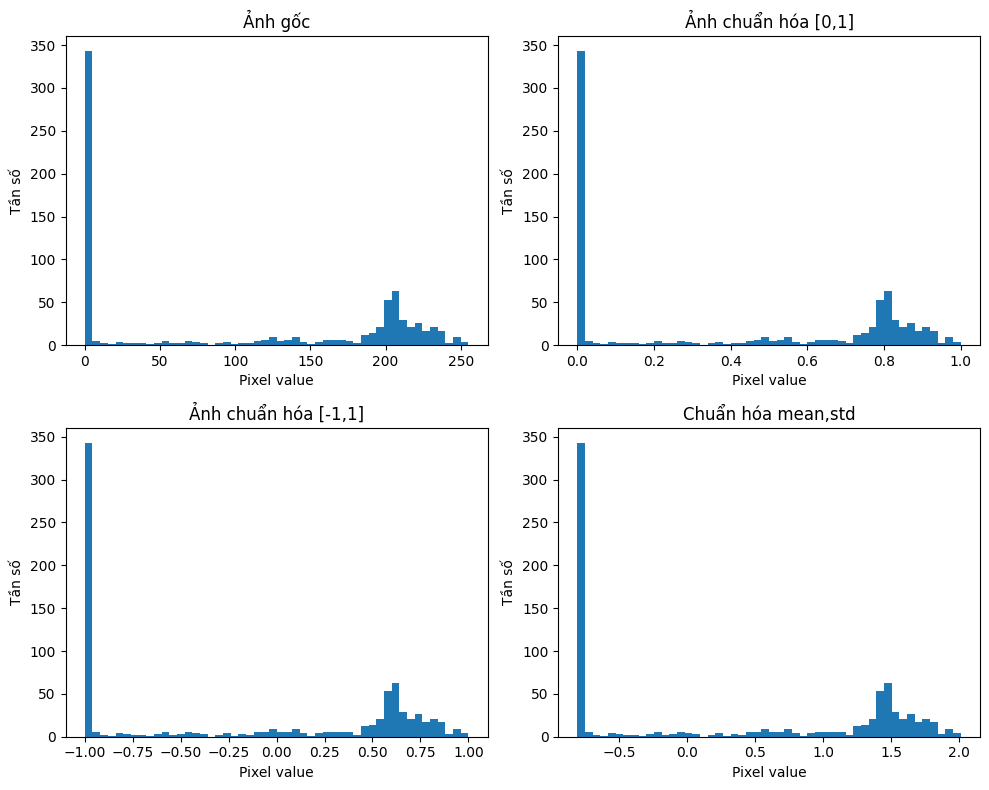

In [6]:
fig = plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.hist(img.flatten(), bins=50)
plt.title("Ảnh gốc")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,2)
plt.hist(img_01.flatten(), bins=50)
plt.title("Ảnh chuẩn hóa [0,1]")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,3)
plt.hist(img_m11.flatten(), bins=50)
plt.title("Ảnh chuẩn hóa [-1,1]")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,4)
plt.hist(img_standardized.flatten(), bins=50)
plt.title("Chuẩn hóa mean,std")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.tight_layout()
plt.show()


Quan sát histogram cho thấy tất cả các phương pháp chuẩn hóa đều giữ nguyên hình dạng phân phối. Điều này là do các phương pháp như min–max scaling và standardization chỉ là các phép biến đổi tuyến tính, chỉ thay đổi thang đo hoặc dịch chuyển giá trị pixel mà không làm thay đổi mối quan hệ tương đối giữa các pixel.

Min–max normalization nén dữ liệu vào khoảng [0,1] hoặc [-1,1], giúp giảm độ lớn giá trị và tăng tính ổn định số khi huấn luyện mô hình. Trong khi đó, standardization đưa dữ liệu về trung bình 0 và độ lệch chuẩn 1, tạo phân phối tập trung quanh 0, giúp các thuật toán học máy hội tụ nhanh hơn.

Mặc dù ảnh sau chuẩn hóa nhìn gần như không thay đổi, nhưng các đặc tính thống kê của dữ liệu đã được cải thiện đáng kể, từ đó hỗ trợ quá trình huấn luyện hiệu quả hơn.

---
## d) Edge Detection (Optional Bonus)

#### **Yêu cầu bài làm**
-  Apply edge detection algorithms (Sobel, Prewitt, Canny)
- Extract
edge features from images
- Visualize detected edges and discuss their significance for your
chosen dataset

#### **Trích xuất cạnh bằng Sobel**

In [7]:
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize = 3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize = 3)

sobel = np.sqrt(sobelx**2 + sobely**2)
sobel = np.clip(sobel,0,255)
sobel = np.uint8(sobel)




#### **Trích xuất cạnh bằng Prewitt**

In [8]:
kernelx = np.array([ [1,0,-1],
                    [1,0,-1],
                    [1,0,-1]])

kernely = np.array([ [1,1,1],
                    [0,0,0],
                    [-1,-1,-1]])

prewittx = cv2.filter2D(img,-1 , kernelx)
prewitty = cv2.filter2D(img, -1, kernely)

prewitt = np.sqrt(prewittx**2 + prewitty**2)
prewitt = np.clip(prewitt,0,255)
prewitt = np.uint8(prewitt)


#### **Trích xuất cạnh bằng Canny**

In [9]:
canny = cv2.Canny(img.astype(np.uint8), threshold1=50, threshold2=150)

#### **Lý do chọn giá trị cho các Threshold:**
- Lý do chọn threshold1 là 50 và threshold2 là 150: Trong tài liệu OpenCV khuyến khích chọn tỉ lệ upper:lower 2:1 hoặc 3:1.

Tham khảo: [Canny Edge Detection - OpenCV](https://docs.opencv.org/4.x/da/d5c/tutorial_canny_detector.html)

### **So sánh kết quả của các phương pháp trích xuất**

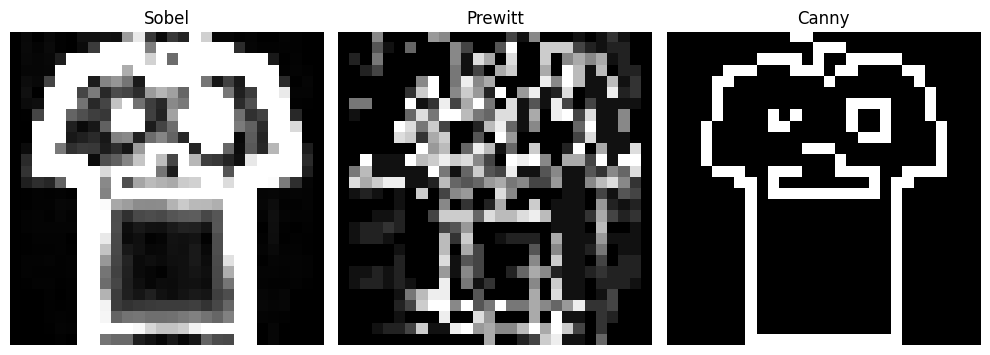

In [10]:
plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.imshow(sobel,cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(prewitt,cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny,cmap='gray')
plt.title("Canny")
plt.axis('off')

plt.tight_layout()
plt.savefig("edges_new.svg", format="svg")


Nhận xét
- Đối với thuật toán Sobel thì trích xuất biên khá dày,sáng mạnh quanh biên áo và còn nhiều texture bên trong áo, không tốt cho trích biên rõ ràng
- Đối với thuật toán Prewitt thì dường như ảnh đã bị vỡ cấu trúc
- Đối với thuật toán Canny cho kết quả trích xuất cạnh tốt nhất vì tạo ra biên mỏng nhất, rõ ràng và ít nhiễu bên trong.

--> Đối với tập dữ liệu Fashion-MNIST thì hình dạng là đặc trưng quan trọng nhất, nên sử dụng thuật toán Canny để trích xuất chính xác đường viền quần áo do đó có thể tạo ra đặc trưng tốt để phân loại đối với dataset này

---
## Áp dụng các bước Pre-processing cho toàn bộ Dataset

Sau khi đã tiến hành quan sát, so sánh và nhận xét. Em sẽ chọn những phương pháp phù hợp nhất ở từng bước và tiến hành apply cho toàn bộ Dataset

In [11]:
N = X.shape[0]

processed_imgs = np.zeros((N, 28, 28), dtype=np.float32)
edges_imgs     = np.zeros((N, 28, 28), dtype=np.uint8)

for i in range(N):
    img = X[i]

    min_pixel = X[i].min()
    max_pixel = X[i].max()
    # ===== 1. Normalize [0,1] =====
    norm = (img - min_pixel) / (max_pixel - min_pixel)

    # ===== 2. Canny edge =====
    canny_edge = cv2.Canny(img.astype(np.uint8), 50, 150)

    processed_imgs[i] = norm
    edges_imgs[i] = canny_edge

print("Processed shape :", processed_imgs.shape)
print("Edges shape     :", edges_imgs.shape)


Processed shape : (10000, 28, 28)
Edges shape     : (10000, 28, 28)


# Trực quan hóa một số ảnh sau tiền xử lí

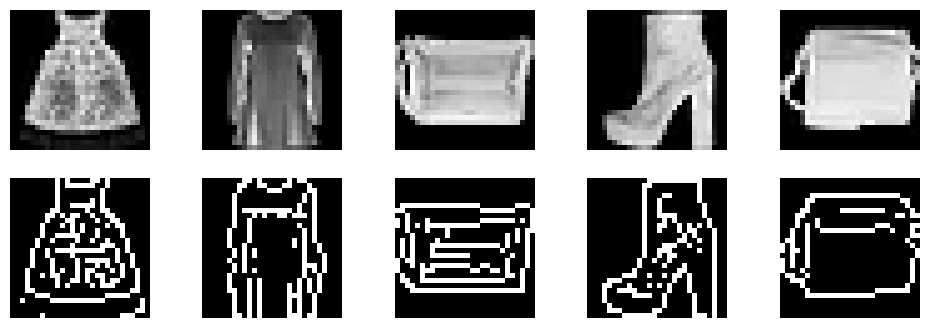

In [12]:
n_show = 5

# random index
idxs = np.random.choice(len(edges_imgs), n_show, replace=False)

plt.figure(figsize=(12,4))

for i, idx in enumerate(idxs):
    plt.subplot(2, n_show, i+1)
    plt.imshow(processed_imgs[idx], cmap='gray')
    plt.axis('off')

    plt.subplot(2, n_show, i+1+n_show)
    plt.imshow(edges_imgs[idx], cmap='gray')
    plt.axis('off')

plt.show()
